# Datasets

Nguyễn Ngọc Hoàng Nam - B23DCCN585 | Assignment 04

**Bản mở rộng:** notebook này giữ nhóm 18 lượt seed 42 để giải thích thuật toán. Notebook **06** tổng hợp đầy đủ 54 lượt nhiều seed và 18 ablation; notebook **07** thực thi ví dụ số học dùng trong báo cáo 78 trang.

In [1]:
from pathlib import Path
import os, sys, json, subprocess
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Hãy mở notebook từ thư mục repository.'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.data import DATASETS, load_data, data_root
print('Python:', sys.version.split()[0])
print('Dữ liệu:', data_root())

Python: 3.10.20
Dữ liệu: E:\PTHTTM\ASG_04_data


## Nguồn dữ liệu

Ba bộ từ Kaggle: [MNIST](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv), [CIFAR-10](https://www.kaggle.com/datasets/pankrzysiu/cifar10-python), [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100).

CIFAR-10 và CIFAR-100 đều có 60.000 ảnh màu 32×32. Chúng phức tạp hơn MNIST vì nền, màu, tư thế, đối tượng tự nhiên; CIFAR-100 có 100 lớp và ít ảnh mỗi lớp. “Big” được hiểu theo số lượng ảnh và độ phức tạp tương đối trong bài thực hành, không đồng nghĩa dữ liệu quy mô ImageNet.

In [2]:
missing=[name for name in DATASETS if not (data_root()/(name+'.npz')).exists()]
if missing:
    from src.download_data import download
    download()
else:
    print('Đã có đủ dữ liệu đã chuẩn bị; không tải lại.')
manifest=json.loads((ROOT/'results/dataset_manifest.json').read_text())
display(pd.DataFrame(manifest)[['dataset','train','validation','test','classes','shape','kaggle_url']])

Đã có đủ dữ liệu đã chuẩn bị; không tải lại.


,dataset,train,validation,test,classes,shape,kaggle_url
0,mnist,54001,5999,10000,10,"[1, 28, 28]",https://www.kaggle.com/datasets/oddrationale/m...
1,cifar10,45000,5000,10000,10,"[3, 32, 32]",https://www.kaggle.com/datasets/pankrzysiu/cif...
2,cifar100,45000,5000,10000,100,"[3, 32, 32]",https://www.kaggle.com/datasets/fedesoriano/ci...


## Chia tập và tiền xử lý

Giữ test chính thức. Tách validation 10% theo từng lớp từ training gốc, seed 42. MNIST: 54.001/5.999/10.000; CIFAR: 45.000/5.000/10.000. Không lấy mẫu con. Dữ liệu lưu uint8 để tiết kiệm RAM, chỉ đổi minibatch sang float32/255 khi dùng. Nhãn là số nguyên, loss sparse cross-entropy. Không fit bước tiền xử lý nào trên test.

File split và SHA-256 giúp kiểm tra hai backend có dùng đúng các mẫu giống nhau. Định dạng lưu chung NCHW; TensorFlow nhận NHWC sau transpose.

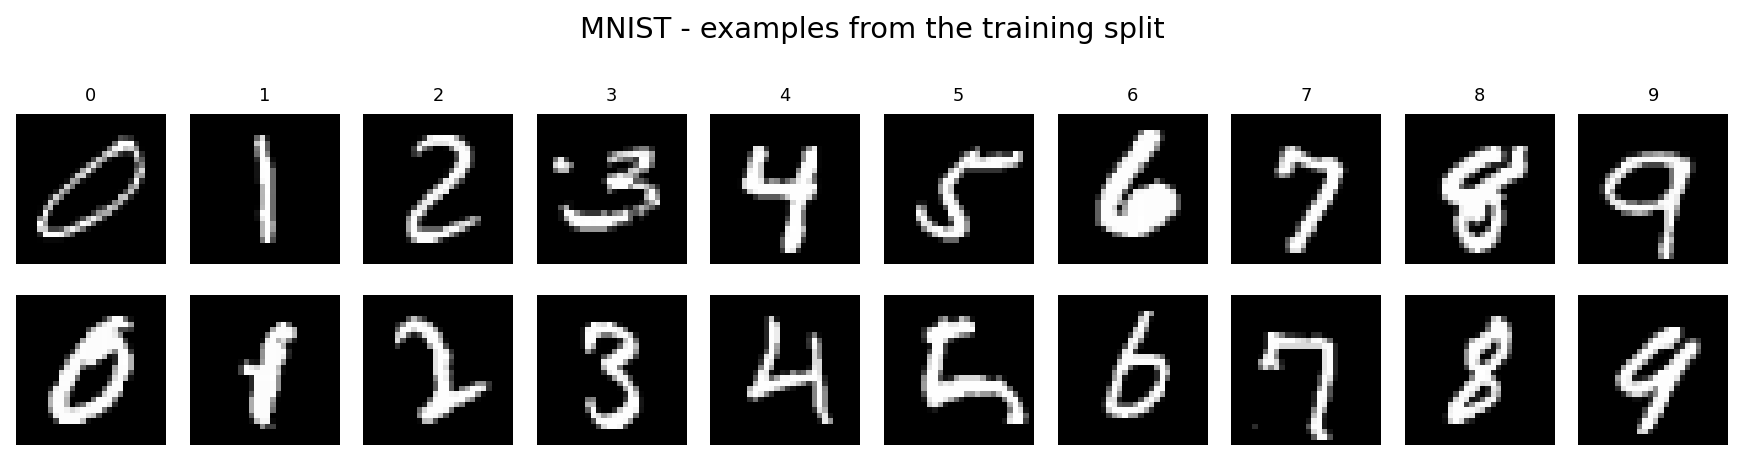

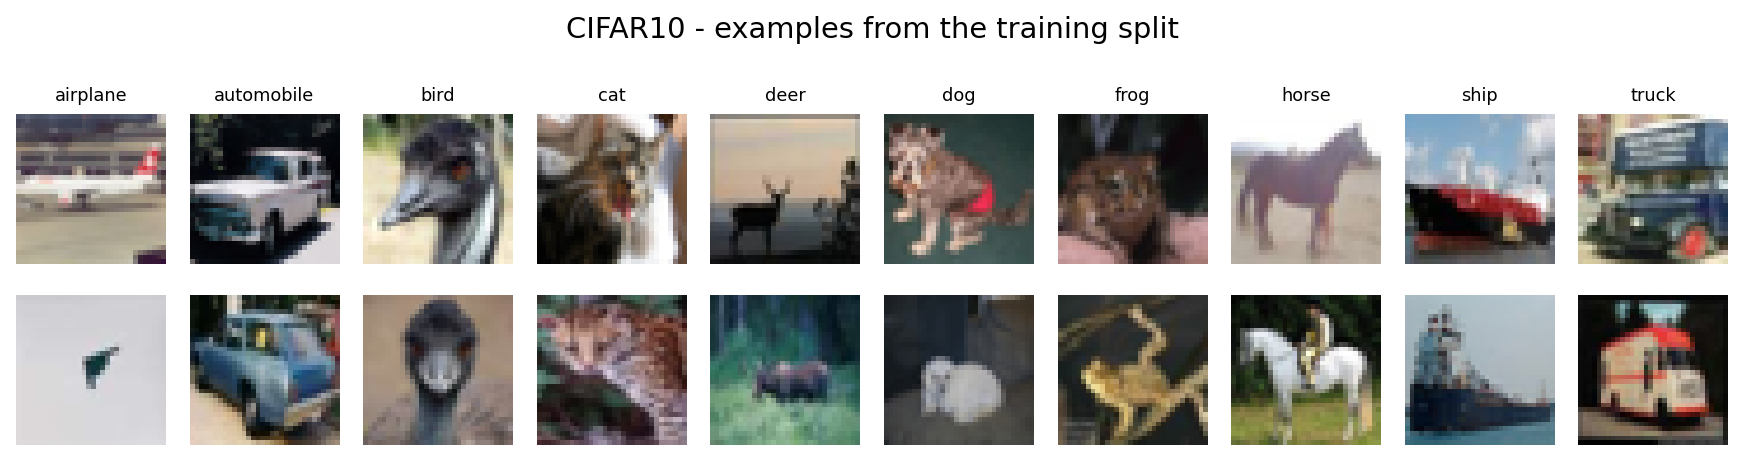

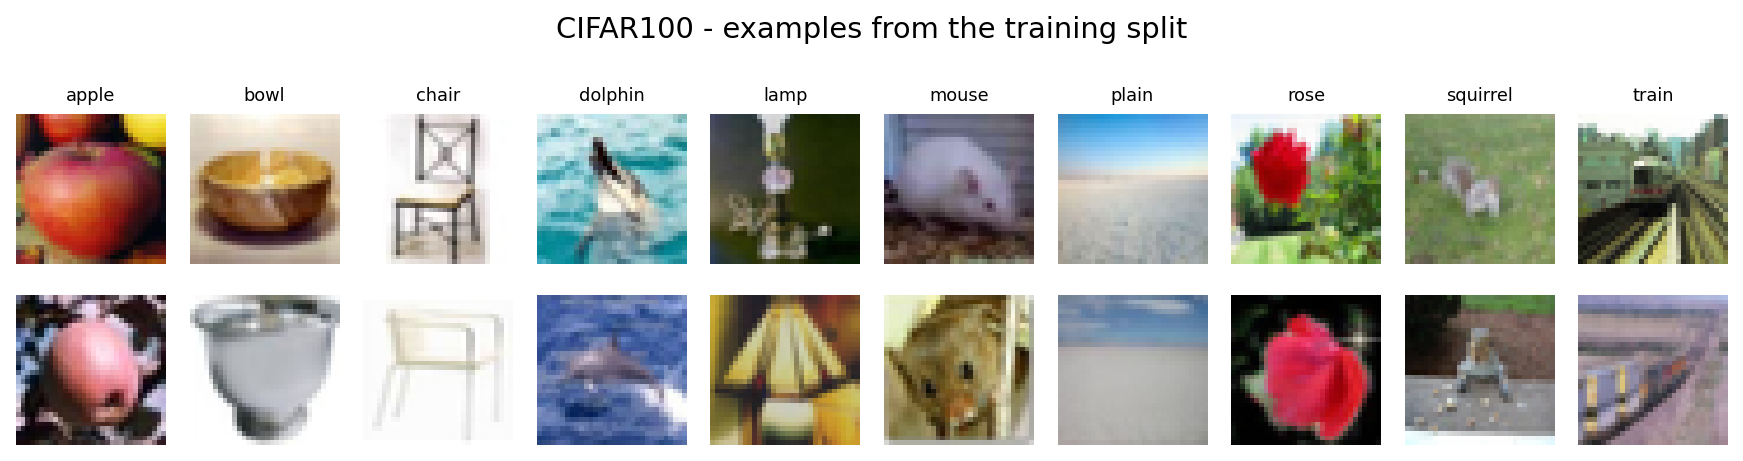

,dataset,train_shape,pixel_min,pixel_max,all_indices_used
0,mnist,"(1, 1, 28, 28)",0,255,True
1,cifar10,"(1, 3, 32, 32)",0,255,True
2,cifar100,"(1, 3, 32, 32)",0,255,True


In [3]:
checks=[]
for name,cfg in DATASETS.items():
    d=load_data(name); ti,vi=d['train_ids'],d['val_ids']
    assert set(ti).isdisjoint(set(vi))
    assert len(ti)+len(vi)==len(d['y'])
    assert np.array_equal(np.sort(np.concatenate([ti,vi])),np.arange(len(d['y'])))
    assert d['x'].dtype==np.uint8
    checks.append(dict(dataset=name,train_shape=str(d['x'][ti[:1]].shape),pixel_min=int(d['x'].min()),pixel_max=int(d['x'].max()),all_indices_used=True))
    display(Image(filename=str(ROOT/'figures'/f'{name}_samples.png')))
display(pd.DataFrame(checks))

In [4]:
audit=json.loads((ROOT/'results/dataset_audit.json').read_text())
display(pd.DataFrame(audit).drop(columns=['duplicate_policy']))

,dataset,dtype,pixel_min,pixel_max,finite,labels_valid,split_indices_disjoint,all_training_indices_used,unique_training_images,exact_image_hashes_shared_train_validation,exact_image_hashes_shared_train_test,exact_image_hashes_shared_validation_test
0,mnist,uint8,0,255,True,True,True,True,60000,0,0,0
1,cifar10,uint8,0,255,True,True,True,True,50000,0,0,0
2,cifar100,uint8,0,255,True,True,True,True,49986,4,8,2


## Kiểm tra trùng ảnh và giới hạn

Các chỉ số train/validation/test không giao nhau. Kiểm tra SHA-256 pixel không thấy ảnh trùng hoàn toàn giữa các phần MNIST/CIFAR-10. CIFAR-100 có 4 hash ảnh chung train-validation, 8 chung train-test và 2 chung validation-test. Giữ benchmark chính thức và công khai hạn chế này; không thay đổi dữ liệu theo kết quả test. Kiểm tra exact hash không phát hiện ảnh gần giống.

Vì có trùng pixel ở CIFAR-100, không khẳng định dữ liệu hoàn toàn không rò rỉ nội dung. Phần phân tích có thêm độ nhạy của accuracy khi loại các ảnh test đã xuất hiện trong training gốc; số này bổ sung cho metric benchmark chính thức.

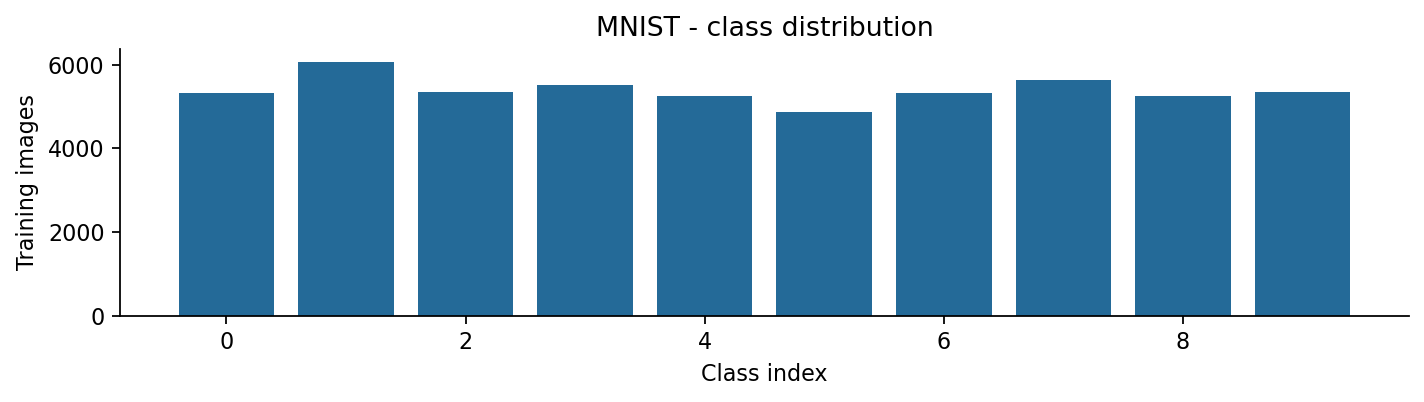

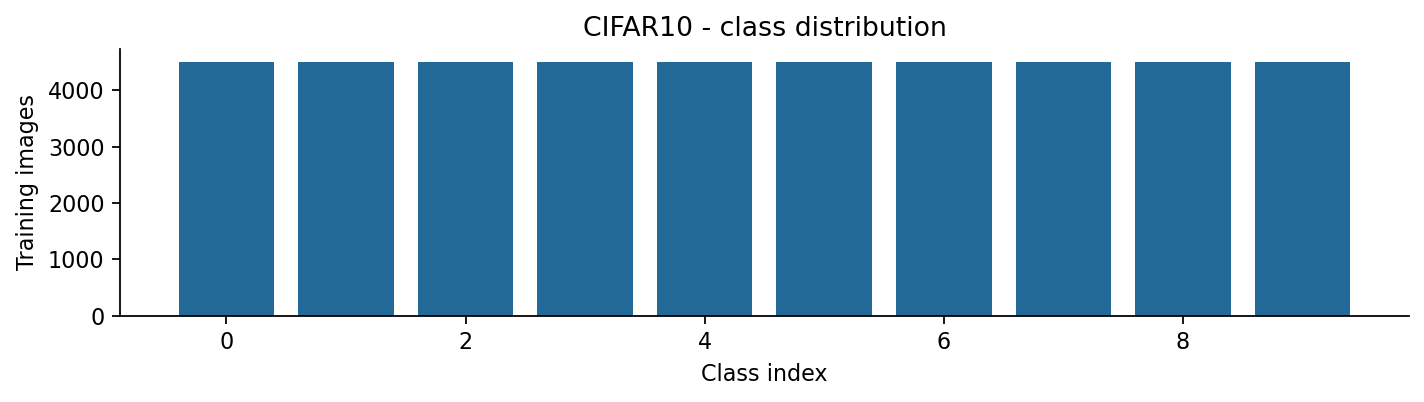

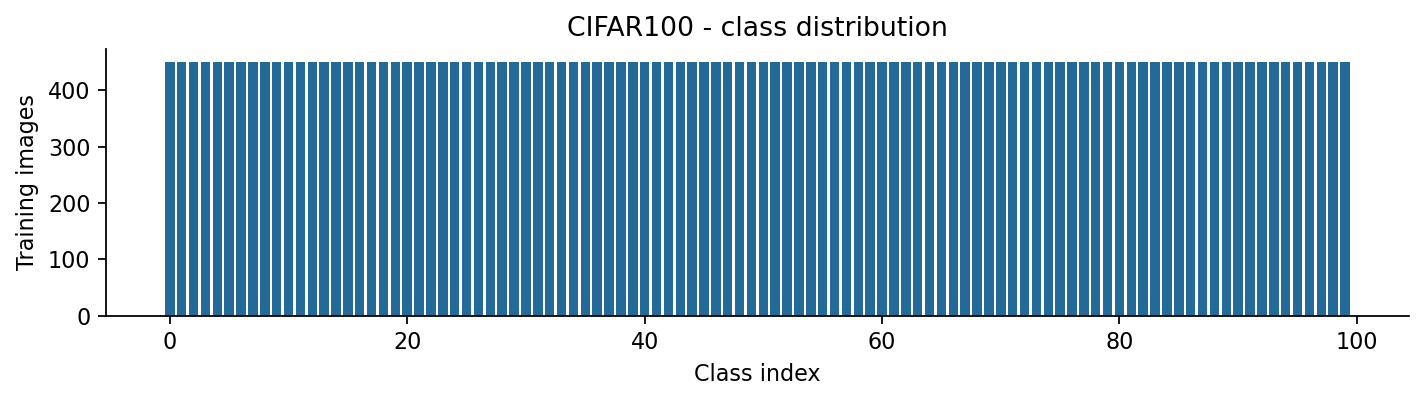

In [5]:
for name in DATASETS:
    display(Image(filename=str(ROOT/'figures'/f'{name}_distribution.png')))

## Dữ liệu đã chuẩn bị trước

Diabetes, VN housing và đánh giá quần áo có thể dành cho bài CNN 1D theo slide nếu được yêu cầu bổ sung. Dữ liệu bảng không có tính lân cận tự nhiên như ảnh; văn bản cần tokenize/embedding trước Conv1D. Chúng không được ghép vào ba thí nghiệm ảnh hiện tại.